### Libraries

In [790]:
import pandas as pd
import numpy as np

# Others
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Model Development Core Libs
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#Scaling, Onehot Encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

#Standard Linear Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error

#RF Model
from sklearn.ensemble import RandomForestRegressor

#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


### Reading in the data

In [791]:
working_directory = Path.cwd().parent.parent
print(working_directory)
hist_driver_points_price = working_directory / "data" / "semi-clean" / "hist_driver_points_df_v1.csv"
curr_week_driver_points_price = working_directory / "data" / "semi-clean" / "current_week_driver_points_df_v1.csv"
elo_table = working_directory / "data" / "semi-clean" / "elo_table.csv"
placement_df_path = working_directory / "data" / "clean" / "placement_table.csv"
race_session_info_path = working_directory / "data" / "clean" / "race_session_meeting_info.csv"

/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject


In [792]:
hist = pd.read_csv(hist_driver_points_price).drop(columns=["Unnamed: 0"])
hist.head()

,year,race_num,race_name,location,start_date,driver,price,points,constructor,country_code,meeting_key_x,month,start_epoch,meeting_key_y,price_change_prev_race,price_rank,points_last_three_avg,points_last_five_avg,ppm_last_3,ppm_last_5
0,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,VER,26.9,35.0,RBR,BRN,1141,3,1678028400,1141,NaN,1.0,NaN,NaN,NaN,NaN
1,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,HAM,23.7,19.0,MER,BRN,1141,3,1678028400,1141,NaN,2.0,NaN,NaN,NaN,NaN
2,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,LEC,21.2,-11.0,FER,BRN,1141,3,1678028400,1141,NaN,3.0,NaN,NaN,NaN,NaN
3,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,RUS,18.6,16.0,MER,BRN,1141,3,1678028400,1141,NaN,4.0,NaN,NaN,NaN,NaN
4,2023,1,Bahrain Grand Prix,Sakhir,2023-03-05 15:00:00+00:00,PER,18.0,28.0,RBR,BRN,1141,3,1678028400,1141,NaN,5.0,NaN,NaN,NaN,NaN


In [793]:
curr = pd.read_csv(curr_week_driver_points_price).drop(columns=["Unnamed: 0"])
curr.head()

,year,race_num,race_name,location,start_date,driver,price,points,constructor,country_code,meeting_key_x,month,start_epoch,meeting_key_y,price_change_prev_race,price_rank,points_last_three_avg,points_last_five_avg,ppm_last_3,ppm_last_5
0,2026,3,Japanese Grand Prix,Suzuka,2026-03-29 05:00:00+00:00,VER,28.1,NaN,RBR,JPN,1281,3,1774760400,1281,0.1,1.0,36.67,44.2,1.30,1.57
1,2026,3,Japanese Grand Prix,Suzuka,2026-03-29 05:00:00+00:00,RUS,28.0,NaN,MER,JPN,1281,3,1774760400,1281,0.3,2.0,34.67,31.2,1.24,1.11
2,2026,3,Japanese Grand Prix,Suzuka,2026-03-29 05:00:00+00:00,NOR,26.8,NaN,MCL,JPN,1281,3,1774760400,1281,-0.3,3.0,13.33,11.0,0.50,0.41
3,2026,3,Japanese Grand Prix,Suzuka,2026-03-29 05:00:00+00:00,PIA,24.9,NaN,MCL,JPN,1281,3,1774760400,1281,-0.3,4.0,2.33,7.8,0.09,0.31
4,2026,3,Japanese Grand Prix,Suzuka,2026-03-29 05:00:00+00:00,ANT,23.8,NaN,MER,JPN,1281,3,1774760400,1281,0.3,5.0,35.00,32.0,1.47,1.34


In [794]:
elo = pd.read_csv(elo_table).drop(columns={"Unnamed: 0"})
elo.head()

,driver,driver_number,position,points,gap_to_leader,meeting_key,session_key,dnf,dns,dsq,nc,start_date,race_num,year,elo_position,elo_before,elo_delta,elo_after
0,VER,1,1.0,25.0,0,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,1.0,1500.0,76.0,1576.0
1,PER,11,2.0,18.0,11.987,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,2.0,1500.0,68.0,1568.0
2,ALO,14,3.0,15.0,38.637,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,3.0,1500.0,60.0,1560.0
3,SAI,55,4.0,12.0,48.052,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,4.0,1500.0,52.0,1552.0
4,HAM,44,5.0,10.0,50.977,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,5.0,1500.0,44.0,1544.0


In [795]:
placement_df = pd.read_csv(placement_df_path)

In [796]:
race_session_info = pd.read_csv(race_session_info_path)

#### Filtering doen elo to just needed columns

In [797]:
elo = elo[["race_num", "year", "driver", "elo_before", "elo_after"]]

## Data Cleaning and Quality Checks

In [798]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443 entries, 0 to 1442
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1443 non-null   int64  
 1   race_num                1443 non-null   int64  
 2   race_name               1443 non-null   object 
 3   location                1443 non-null   object 
 4   start_date              1443 non-null   object 
 5   driver                  1443 non-null   object 
 6   price                   1443 non-null   float64
 7   points                  1443 non-null   float64
 8   constructor             1442 non-null   object 
 9   country_code            1443 non-null   object 
 10  meeting_key_x           1443 non-null   int64  
 11  month                   1443 non-null   int64  
 12  start_epoch             1443 non-null   int64  
 13  meeting_key_y           1443 non-null   int64  
 14  price_change_prev_race  1357 non-null   

Constructor
- not quite sure why this got brought forth as it should have been cleaned out in driverLevelDataClean, but i will filter it out again

price_change_prev_race (should be the first race rows of 2023, and when there is a substitute for a driver that didnt drive in the last race

Running Averages
- will probably only keep the records that dont have missing values for these running averages a. the non-null count is quite high

In [799]:
hist = hist[~hist["constructor"].isna()]

#### Removing all rows if there is an NAN in hist

In [800]:
hist = hist.dropna()

In [801]:
hist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1357 entries, 20 to 1442
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    1357 non-null   int64  
 1   race_num                1357 non-null   int64  
 2   race_name               1357 non-null   object 
 3   location                1357 non-null   object 
 4   start_date              1357 non-null   object 
 5   driver                  1357 non-null   object 
 6   price                   1357 non-null   float64
 7   points                  1357 non-null   float64
 8   constructor             1357 non-null   object 
 9   country_code            1357 non-null   object 
 10  meeting_key_x           1357 non-null   int64  
 11  month                   1357 non-null   int64  
 12  start_epoch             1357 non-null   int64  
 13  meeting_key_y           1357 non-null   int64  
 14  price_change_prev_race  1357 non-null   floa

#### early drops 
- start date because it is redundent and model cant use datetimes

In [802]:
hist = hist.drop(columns =["start_date"])
curr = curr.drop(columns =["start_date"])

### Outliers

In [803]:
hist.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'points', 'constructor', 'country_code', 'meeting_key_x', 'month',
       'start_epoch', 'meeting_key_y', 'price_change_prev_race', 'price_rank',
       'points_last_three_avg', 'points_last_five_avg', 'ppm_last_3',
       'ppm_last_5'],
      dtype='object')

In [804]:
numeric_types = ['year', 'race_num', 'price', 'points', "month", 'start_epoch', 
                 'price_change_prev_race', 'price_rank', 'points_last_three_avg', 'points_last_five_avg', 
                 'ppm_last_3', 'ppm_last_5']

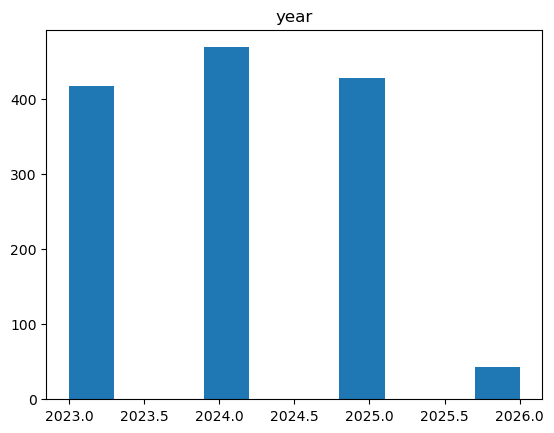

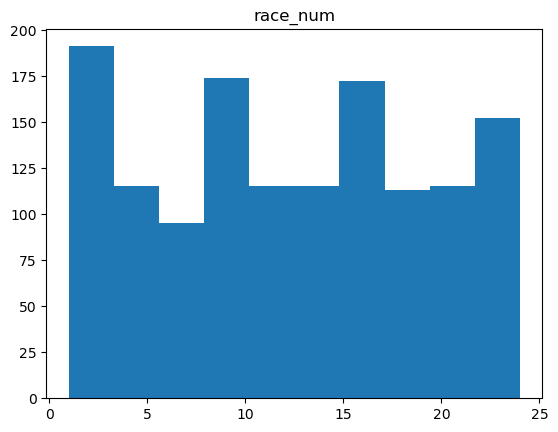

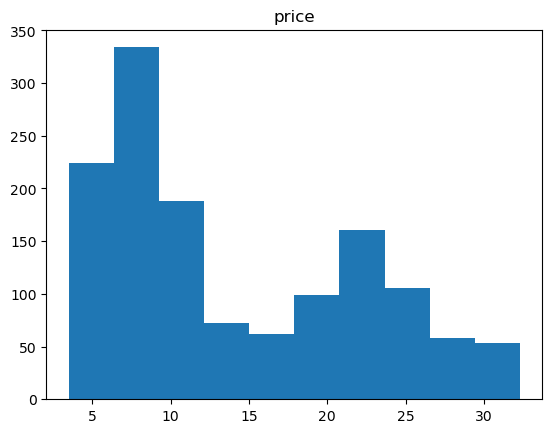

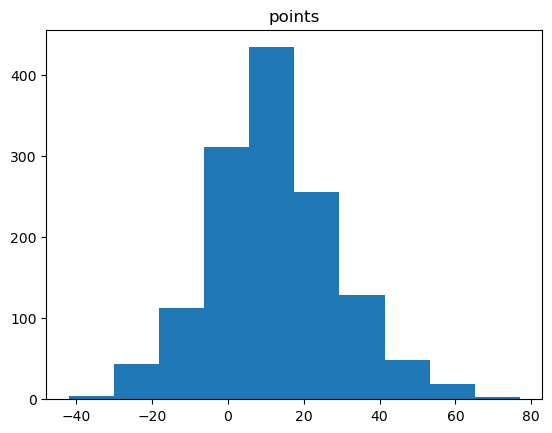

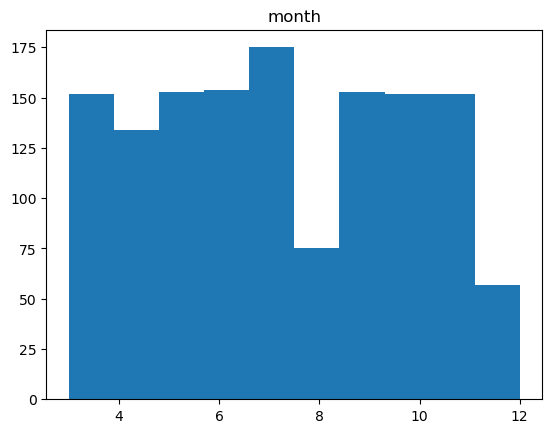

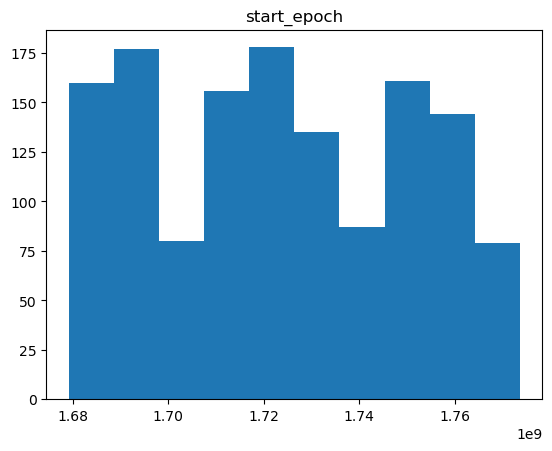

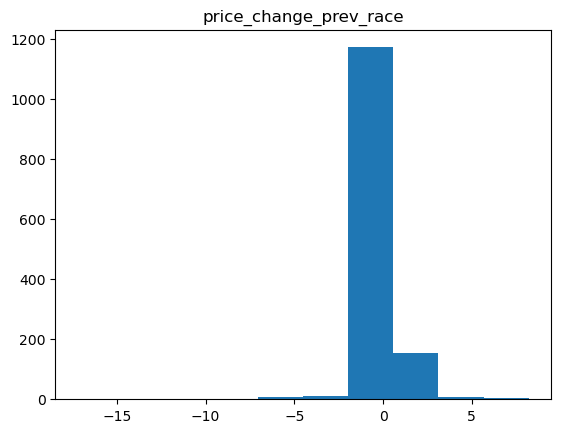

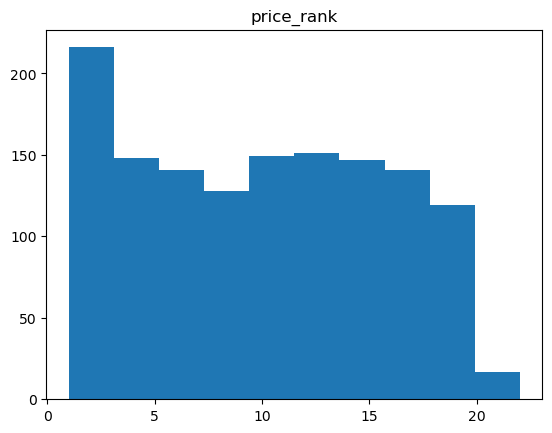

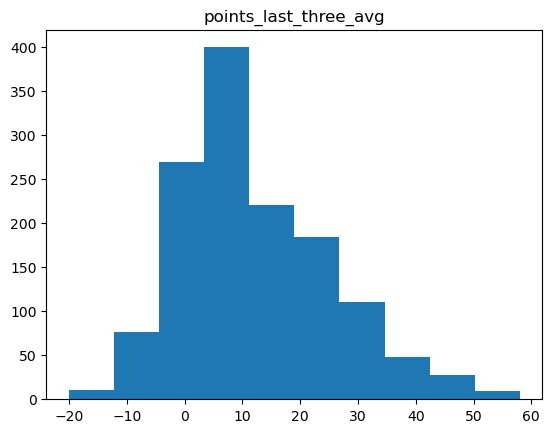

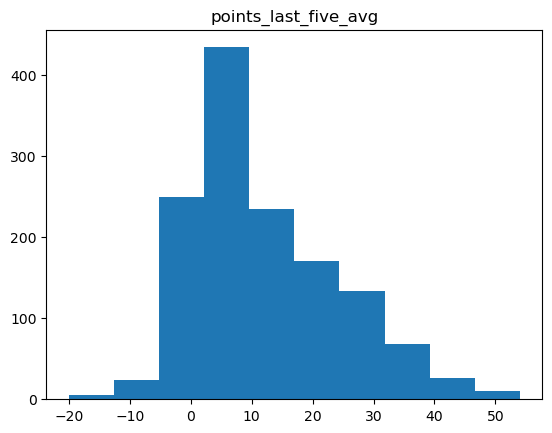

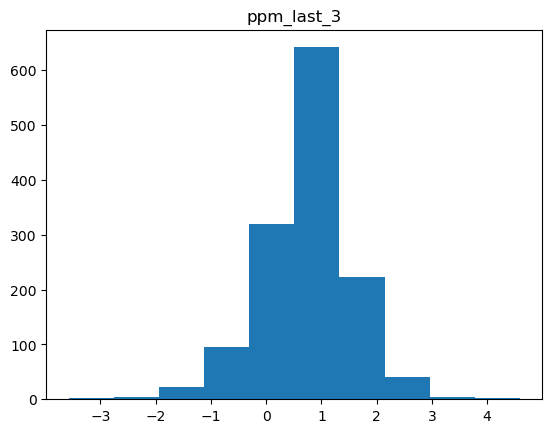

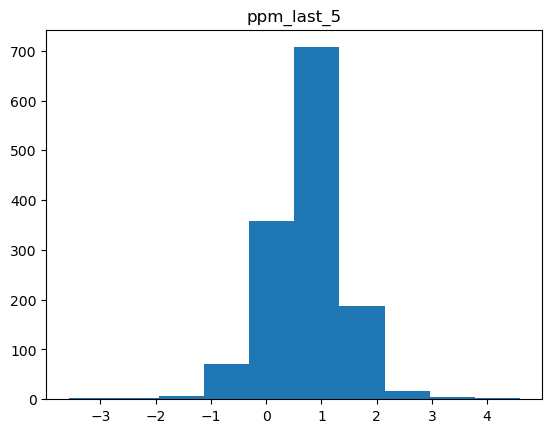

In [805]:
for col in numeric_types:
    plt.figure()
    plt.hist(hist[col])
    plt.title(col)
    plt.show()

#### Looks like all of the quantitative vars check out with no apparent outliers and are within expected ranges
#### Target Variable Points, looks very normal (yay!)

## EDA

#### Niave Baseline Model
- predicting mean values
- accuracy will be based on RMSE

In [806]:
hist['points'].skew()

np.float64(0.3352518662947438)

given the skew is roughly symmetric we will use mean for the niave model

In [807]:
mean_points = np.mean(hist["points"])
mean_points

np.float64(12.15327929255711)

In [808]:
target = "points"

X = hist.drop(columns=[target])
y = hist[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [809]:
baseline_pred = y_train.mean()

In [810]:
y_pred = np.repeat(baseline_pred, len(y_test))
med_pred = np.repeat(y_train.median, len(y_test))

In [811]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 12.48605313092979
Baseline RMSE: 16.522529381677334


every model from this point forward needs to be better than this or it is worse than niave and it is useless

#### Correlations

In [812]:
numeric_df = hist.select_dtypes(include=["number"])

In [813]:
corr_matrix = numeric_df.corr(method='pearson')

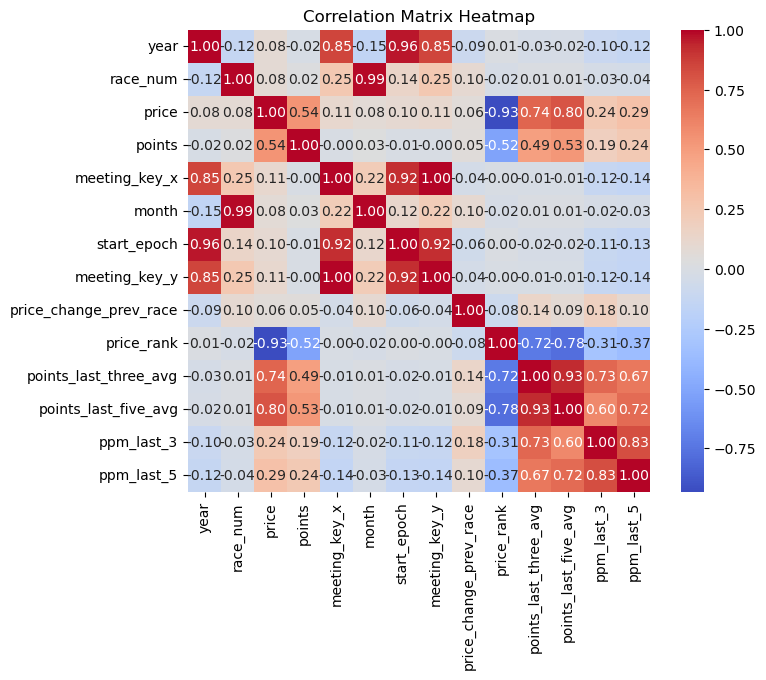

In [814]:
# Set up the Matplotlib figure
plt.figure(figsize=(8, 6))

# Create the Seaborn heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Add a title
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

Target Relationships
- price: .55 (higher price, higher points)
- points_last_three_avg: .49 (higher recent performance, more points)
- points_last_five_avg: .53 (higher recent performance, more points)
- ppm_last_3: .19 (higher recent performance, more points)
- ppm_last_5: .23 (higher recent performance, more points)
- price_rank: -.53 (lower rank, more points)

#### dropping cols with Multicollinearity
- month is highly correlated to race_num
- price_rank is essentially derived from price, so remove
- the running averages are also highly correlate , best to just keep the last 3 and 5 race averages. Will use create a momentum var that will take into account recent vs last 5 changes

## Marriage

In [815]:
married = pd.concat([hist, curr], ignore_index=True)

In [816]:
#ensure our years are right
married['year'].value_counts()

year
2024    469
2025    428
2023    417
2026     65
Name: count, dtype: int64

In [817]:
#null values (first row, will be filled with zero)
married["momentum"] = (
    married["points_last_three_avg"] - married["points_last_five_avg"]
).fillna(0)

In [818]:
married = married.drop(columns=["month", "price_rank", "points_last_three_avg", "ppm_last_3"])

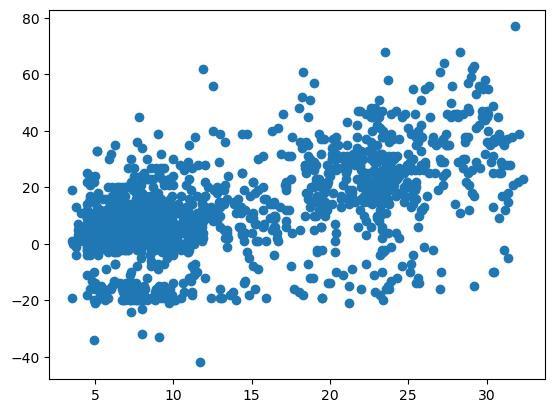

In [819]:
plt.scatter(hist["price"], hist["points"])

### Checking for Heteroscedasity


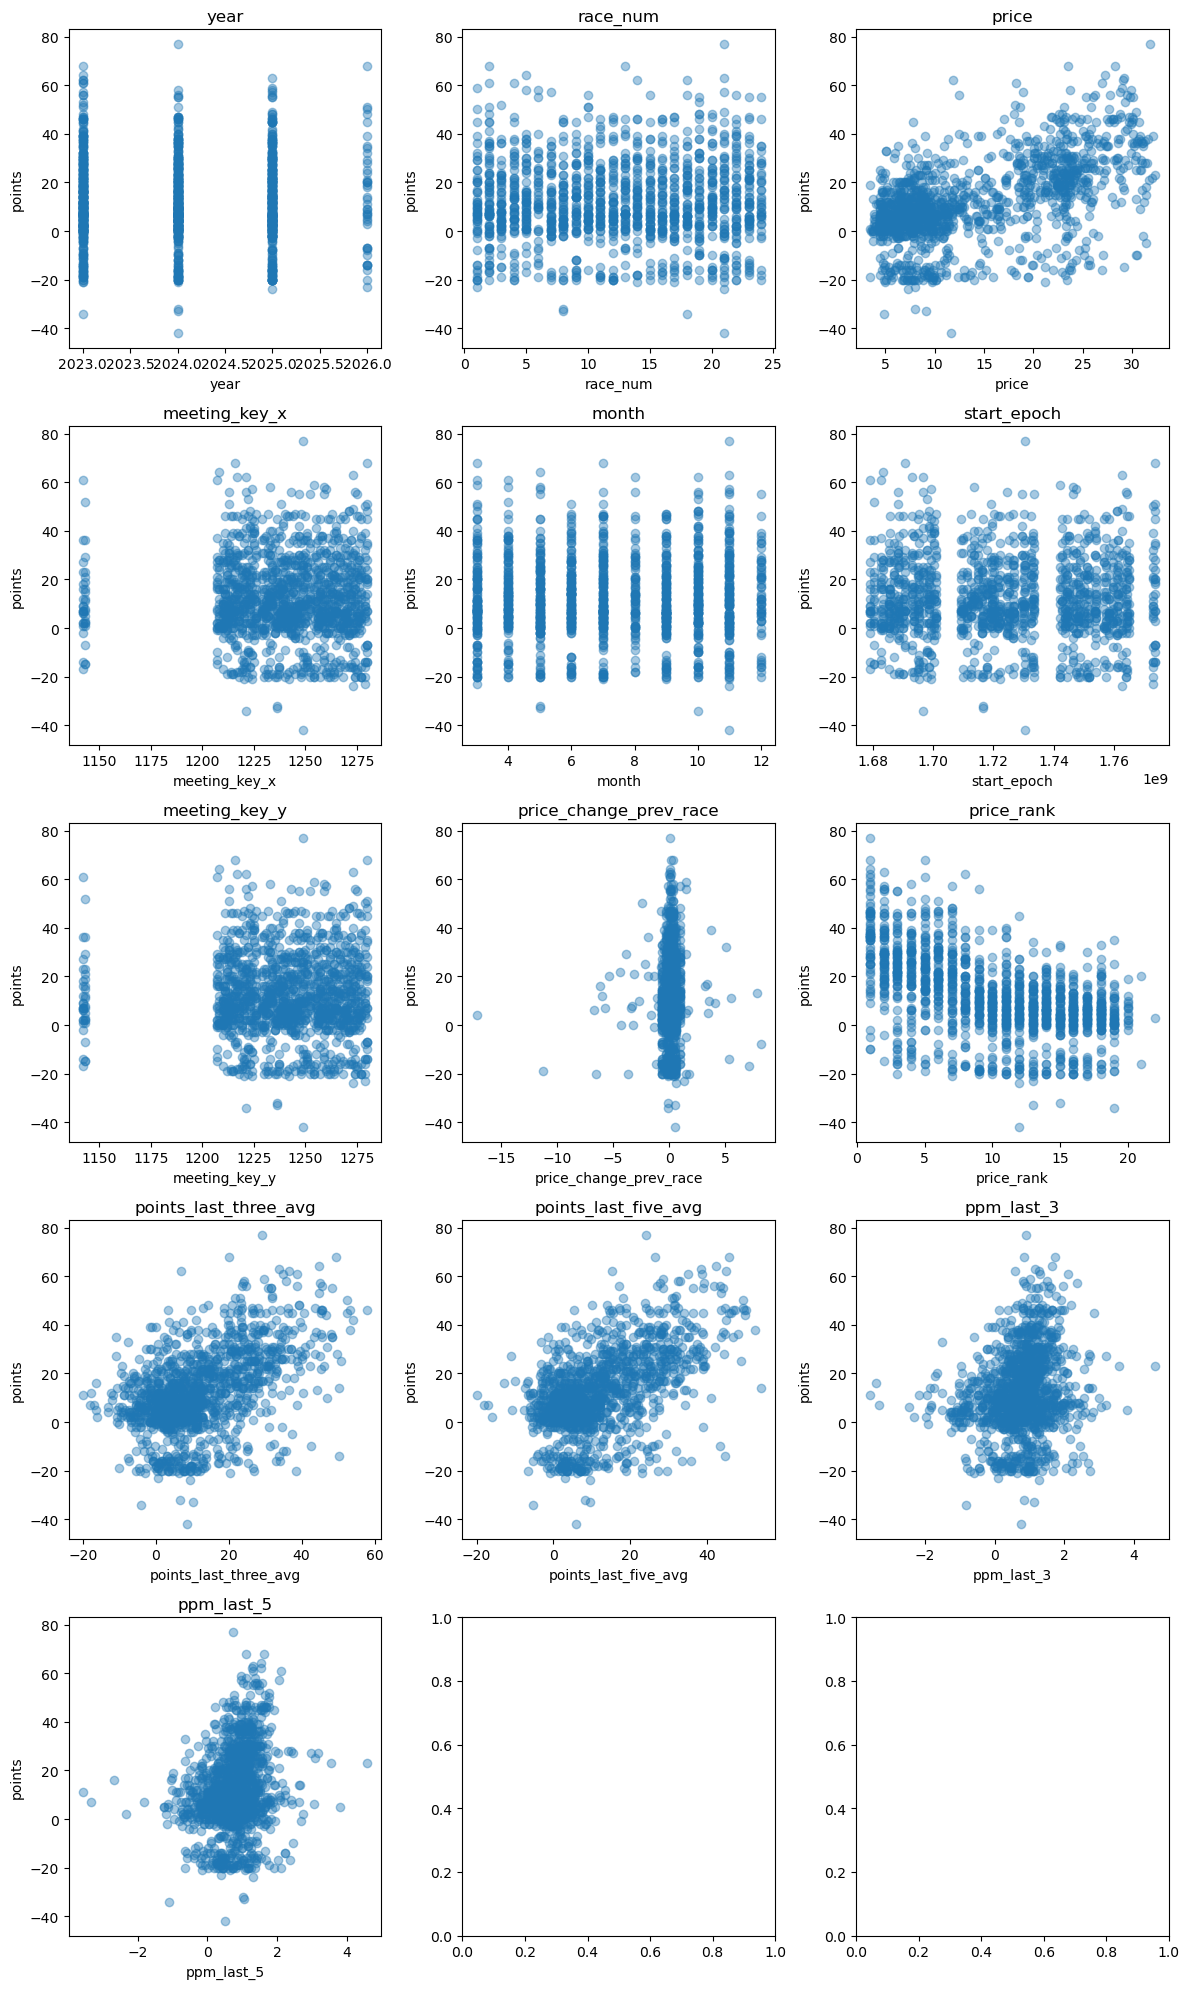

In [820]:
numeric_cols = hist.select_dtypes(include="number").columns.drop("points")

n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows*4))

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.scatter(hist[col], hist["points"], alpha=0.4)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("points")

plt.tight_layout()
plt.show()

## Analysis of relationships with Points

- Strong Relationships: price, points_last_five_avg
- Moderate: ppm_last_5, race_num, momentum
- weak: price_change_prev_race

## Pre-processing


### Feature Engineering

#### Adding Elo to the Married set

In [821]:
elo.tail(40)

,race_num,year,driver,elo_before,elo_after
1385,24,2025,GAS,1348.645605,1316.241418
1386,24,2025,COL,1318.380826,1282.768976
1387,1,2026,RUS,1749.391824,1783.152107
1388,1,2026,ANT,1600.265487,1651.806701
1389,1,2026,LEC,1655.681365,1688.822308
1390,1,2026,HAM,1561.813454,1604.980614
1391,1,2026,NOR,1724.371496,1729.932526
1392,1,2026,VER,1842.664614,1824.342376
1393,1,2026,BEA,1504.893267,1535.683377
1394,1,2026,LIN,1500.000000,1523.795914


In [822]:
def get_current_week_race_num():
    today_dt = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    #calendar load
    file_path = working_directory / "data" / "clean" / "race_session_meeting_info.csv"
    calendar = pd.read_csv(file_path).drop(columns=["Unnamed: 0"])

    #getting the current race number
    calendar["start_date"] = pd.to_datetime(calendar["start_date"], utc=True)
    next_race_int = calendar.loc[calendar["start_date"] >= today_dt, "race"].iloc[0].astype(int)

    #getting current year

    today_dt = pd.to_datetime(today_dt)
    year = today_dt.year


    return next_race_int, year


In [823]:
current_race_num, current_year = get_current_week_race_num()
print(current_race_num, current_year)

3 2026


In [824]:
married = married.merge(elo, how="left", on=["year", "race_num", "driver"])
married = married.rename(
    columns={"elo_before": "driver_elo"}
)

##### need to pull forward this weeks elos
- if not, then this weeks elo scores will be na

In [825]:
latest_elo = (
    elo.sort_values(["driver", "year", "race_num"])
    .groupby("driver", as_index=False)
    .tail(1)[["driver", "elo_after"]]
    .rename(columns={"elo_after": "latest_elo_after"})
)

married = married.merge(
    latest_elo,
    on="driver",
    how="left"
)

mask_current = (
    (married["year"] == current_year) &
    (married["race_num"] == current_race_num) &
    (married["driver_elo"].isna())
)

married.loc[mask_current, "driver_elo"] = married.loc[
    mask_current, "latest_elo_after"
]

# fill DNS / historical gaps
married["driver_elo"] = married["driver_elo"].fillna(
    married["latest_elo_after"]
)

# remove helper column
married = married.drop(columns=["latest_elo_after", "elo_after", "meeting_key_x", "meeting_key_y"])

In [826]:
married.head()

,year,race_num,race_name,location,driver,price,points,constructor,country_code,start_epoch,price_change_prev_race,points_last_five_avg,ppm_last_5,momentum,driver_elo
0,2023,2,Saudi Arabian Grand Prix,Jeddah,VER,27.0,61.0,RBR,KSA,1679245200,0.1,35.0,1.30,0.0,1576.0
1,2023,2,Saudi Arabian Grand Prix,Jeddah,HAM,23.7,16.0,MER,KSA,1679245200,0.0,19.0,0.80,0.0,1544.0
2,2023,2,Saudi Arabian Grand Prix,Jeddah,LEC,21.1,27.0,FER,KSA,1679245200,-0.1,-11.0,-0.52,0.0,1432.0
3,2023,2,Saudi Arabian Grand Prix,Jeddah,RUS,18.6,18.0,MER,KSA,1679245200,0.0,16.0,0.86,0.0,1528.0
4,2023,2,Saudi Arabian Grand Prix,Jeddah,PER,18.1,36.0,RBR,KSA,1679245200,0.1,28.0,1.55,0.0,1568.0


In [827]:
married["driver_elo"].isna().sum()

np.int64(0)

In [828]:
missing_elo = married[married["driver_elo"].isna()]

In [829]:
# quick QA
print(married["driver_elo"].isna().sum())
print(married[["year", "race_num", "driver", "driver_elo"]].head())

0
   year  race_num driver  driver_elo
0  2023         2    VER      1576.0
1  2023         2    HAM      1544.0
2  2023         2    LEC      1432.0
3  2023         2    RUS      1528.0
4  2023         2    PER      1568.0


#### Pricing

In [830]:
married['price_increase'] = (married['price_change_prev_race'] > 0).astype(int)
married['price_decrease'] = (married['price_change_prev_race'] < 0).astype(int)


#### Points

features that will allow us to see differences across drivers in the same car with the same constructor. These will act as a proxy for constructor performance

In [831]:
# proxy for constructor performance (car performance)

married["teammate_points_last5"] = (
    married.groupby(["constructor", "race_num"])["points_last_five_avg"]
    .transform(lambda x: x.sum() - x)
)

#driver strength independent of car strength (driver performance)
#positive means that the driver is outperforming teammate
#drivers outperforming their teammate tend to score more points

married["teammate_delta_last5"] = (
    married["points_last_five_avg"] - married["teammate_points_last5"]
)

##### FIXME in future

driver share of team performance (isolates driver dominance within a team)
measures how muhc of the team's perofrmance comes from that driver. Market share within the team

driver_share = (driver recent points) / (driver recent points + teammate recent points)

In [832]:
# need actual driver points and constructor points to build this feature

## Divorce

### Resplitting out Curr Week and Hist data prior to preprocessing

In [833]:
def get_current_week_race_num():
    today_dt = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    #calendar load
    file_path = working_directory / "data" / "clean" / "race_session_meeting_info.csv"
    calendar = pd.read_csv(file_path).drop(columns=["Unnamed: 0"])

    #getting the current race number
    calendar["start_date"] = pd.to_datetime(calendar["start_date"], utc=True)
    next_race_int = calendar.loc[calendar["start_date"] >= today_dt, "race"].iloc[0].astype(int)

    #getting current year

    today_dt = pd.to_datetime(today_dt)
    year = today_dt.year


    return next_race_int, year


In [834]:
current_week_race_num, current_year = get_current_week_race_num()
print(f'Race: {current_week_race_num}, Year: {current_year}')

Race: 3, Year: 2026


In [835]:
curr = married[(married["race_num"] == current_week_race_num) & (married["year"] == current_year)]

In [836]:
key_cols = ["year", "race_num", "driver"]

hist = married.merge(
    curr[key_cols].drop_duplicates(),
    on=key_cols,
    how="left",
    indicator=True
)
hist = hist[hist["_merge"] == "left_only"].drop(columns="_merge")

In [837]:
hist.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'points', 'constructor', 'country_code', 'start_epoch',
       'price_change_prev_race', 'points_last_five_avg', 'ppm_last_5',
       'momentum', 'driver_elo', 'price_increase', 'price_decrease',
       'teammate_points_last5', 'teammate_delta_last5'],
      dtype='object')

### Pre Process Pipeline

In [838]:
hist = hist.sort_values(["start_epoch", "race_num"])
hist = hist.drop(columns=["start_epoch"])

In [839]:
from sklearn.model_selection import train_test_split #for splitting our data into train/test
from sklearn.compose import ColumnTransformer #allows for different preprocessing for different column groups
from sklearn.pipeline import Pipeline #chains steps in order (preprocess, model), prevents leakage
from sklearn.impute import SimpleImputer #fills in missing values in a consistent manner, we should have none
from sklearn.preprocessing import OneHotEncoder, StandardScaler #categories are (1/0) columns, standardizes numeric features
from sklearn.metrics import mean_absolute_error, mean_squared_error #metrics for our error


target = "points"
X = hist.drop(columns=[target])
y = hist[target]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #takes the median value and imputes as necesarry
    ("scaler", StandardScaler())  # keep for linear models; remove for tree models
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)





### Preprocess prediction set seperately
- this will be used after model development

In [867]:
#Standard Linear Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
#RF Model
from sklearn.ensemble import RandomForestRegressor


### Train Test Split

In [841]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=201
)

### Declaring Model Types and Basic Params

In [871]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=201),
    "Lasso": Lasso(alpha=.01, max_iter=20000, random_state=201),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000, random_state=201),
    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=201, min_samples_leaf=5),
    "LightGBM": LGBMRegressor(n_estimators = 200, learning_rate=0.03, num_leaves=7, random_state=201, verbosity=-1)
}

### Model Pipeline

In [872]:
y_train[y_train.isna()]

Series([], Name: points, dtype: float64)

In [873]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
tscv = TimeSeriesSplit(n_splits=5)

results = []
coef_tables = {}

for name, model in models.items():
    # Preprocessing for each model family
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipe,
        X,
        y,
        cv=tscv,
        scoring="neg_mean_absolute_error"
    )

    cv_mae = -cv_scores.mean()
    cv_mae_std = cv_scores.std()
    
    
    pipe.fit(X_train, y_train)
    

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)


    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append((name, cv_mae, cv_mae_std, train_mae, train_rmse, test_mae, test_rmse))

    # 3) Coefs for linear models only
    mdl = pipe.named_steps["model"]
    if hasattr(mdl, "coef_"):
        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
        coefs = np.ravel(mdl.coef_)

        coef_tables[name] = (
            pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
        )

results_df = pd.DataFrame(
    results,
    columns=["model", "CV_MAE", "CV_MAE_STD", "Train_MAE", "Train_RMSE", "Test_MAE", "Test_RMSE"]
).sort_values("CV_MAE")

results_df

/opt/miniconda3/envs/strava/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/strava/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/strava/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/strava/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/strava/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with f

,model,CV_MAE,CV_MAE_STD,Train_MAE,Train_RMSE,Test_MAE,Test_RMSE
4,RandomForest,10.531226,1.083753,6.650760,9.468416,10.164852,13.584199
5,LightGBM,10.535149,1.182828,8.610994,11.916682,10.021740,13.327965
3,ElasticNet,11.283467,1.081926,9.592255,13.307191,10.084273,13.350502
2,Lasso,11.389816,1.119448,9.544870,13.249213,10.113460,13.400723
1,Ridge,11.411535,0.943229,9.552619,13.230746,10.175287,13.433544
0,Linear,12.384797,1.554876,9.545602,13.217874,10.231565,13.516194


- looks like RandomForest is overfitting the data, which is to be expected given the low dimensionality

## Coefficient Analysis

In [874]:
coef_tables = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    mdl = pipe.named_steps["model"]

    if hasattr(mdl, "coef_"):
        coefs = mdl.coef_.ravel()
        feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

        coef_tables[name] = (
            pd.DataFrame({"feature": feature_names, "coef": coefs})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False)
        )
    else:
        print(f"{name}: no coef_ (use feature_importances_ or permutation importance)")

RandomForest: no coef_ (use feature_importances_ or permutation importance)
LightGBM: no coef_ (use feature_importances_ or permutation importance)


In [846]:
coef_tables

{'Linear':                              feature       coef   abs_coef
 88                   cat__driver_VER  28.990432  28.990432
 80                   cat__driver_PER  16.853047  16.853047
 66                   cat__driver_BOT -12.403537  12.403537
 94              cat__constructor_AUD -12.231191  12.231191
 65                   cat__driver_BOR  -9.880437   9.880437
 ..                               ...        ...        ...
 7                    num__driver_elo   0.120063   0.120063
 92              cat__constructor_AMR  -0.090482   0.090482
 121            cat__country_code_QAT  -0.062497   0.062497
 30   cat__race_name_Qatar Grand Prix  -0.062497   0.062497
 43              cat__location_Lusail  -0.062497   0.062497
 
 [125 rows x 3 columns],
 'Ridge':                              feature       coef   abs_coef
 88                   cat__driver_VER  17.946878  17.946878
 94              cat__constructor_AUD -10.406779  10.406779
 66                   cat__driver_BOT  -9.057956   9.0

In [847]:
coef_tables["ElasticNet"][coef_tables["ElasticNet"]["feature"].str.contains("elo", case=False)]

,feature,coef,abs_coef
7,num__driver_elo,1.263359,1.263359
38,cat__location_Barcelona,-0.038935,0.038935


In [848]:
elo_scaled = (X["driver_elo"] - X["driver_elo"].mean()) / X["driver_elo"].std()
elo_contribution = elo_scaled * 1.087
elo_contribution.describe()

count    1.357000e+03
mean     3.141678e-17
std      1.087000e+00
min     -2.195527e+00
25%     -7.901529e-01
50%     -2.440557e-01
75%      7.905109e-01
max      2.916855e+00
Name: driver_elo, dtype: float64

In [849]:
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

search_spaces = {
    "Ridge": (
        Ridge(random_state=201),
        {"model__alpha": [0.01, 0.1, 1, 10, 100]}
    ),
    "Lasso": (
        Lasso(max_iter=20000, random_state=201),
        {"model__alpha": [0.0005, 0.001, 0.01, 0.1, 1]}
    ),
    "ElasticNet": (
        ElasticNet(max_iter=20000, random_state=201),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1],
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=201, n_jobs=-1),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 3, 5]
        }
    )
}

tuning_results = []
best_pipes = {}

for name, (model, grid_params) in search_spaces.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grid=grid_params,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_pipes[name] = grid.best_estimator_
    cv_mae = -grid.best_score_

    test_pred = best_pipes[name].predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)

    tuning_results.append([name, cv_mae, test_mae, grid.best_params_])

pd.DataFrame(tuning_results, columns=["model", "best_cv_mae", "test_mae", "best_params"]).sort_values("best_cv_mae")

,model,best_cv_mae,test_mae,best_params
0,Ridge,10.078563,9.966690,{'model__alpha': 100}
2,ElasticNet,10.081948,10.006105,"{'model__alpha': 1, 'model__l1_ratio': 0.9}"
1,Lasso,10.094504,9.984199,{'model__alpha': 1}
3,RandomForest,10.320373,10.104155,"{'model__max_depth': 10, 'model__min_samples_l..."


Best Model:
model: ElasticNet
params: alpha: 1, model_l1_ratio: 0.9

In [850]:
import joblib
from pathlib import Path

out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

# if you used GridSearchCV:
best_pipe = grid.best_estimator_   # already fitted

joblib.dump(best_pipe, out_dir / "elasticnet_best_pipe.joblib")

['models/elasticnet_best_pipe.joblib']

In [851]:
import joblib
from pathlib import Path

out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

# if you used GridSearchCV:
best_pipe = grid.best_estimator_   # already fitted

joblib.dump(best_pipe, out_dir / "elasticnet_best_pipe.joblib")
import json

meta = {
    "model_name": "ElasticNet",
    "best_params": grid.best_params_,
    "cv_mae": float(-grid.best_score_),
    "features": list(X.columns),
}
with open("models/elasticnet_best_pipe_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

In [852]:
import joblib
import pandas as pd
import json

# 1) load fitted pipeline
best_pipe = joblib.load("models/elasticnet_best_pipe.joblib")

# (optional) load metadata so you know exactly what columns it expects
with open("models/elasticnet_best_pipe_meta.json", "r") as f:
    meta = json.load(f)

feature_cols = meta["features"]  # these are the raw columns from X.columns when you trained

In [853]:
current_week_df = curr.drop(columns=["points"])
current_week_df.columns

Index(['year', 'race_num', 'race_name', 'location', 'driver', 'price',
       'constructor', 'country_code', 'start_epoch', 'price_change_prev_race',
       'points_last_five_avg', 'ppm_last_5', 'momentum', 'driver_elo',
       'price_increase', 'price_decrease', 'teammate_points_last5',
       'teammate_delta_last5'],
      dtype='object')

In [854]:
X_curr = current_week_df.reindex(columns=feature_cols)


Seeing if any features are missing

In [855]:
missing = set(feature_cols) - set(current_week_df.columns)
print(missing)

set()


## Predicting Current Week Points

In [856]:
pred_points = best_pipe.predict(X_curr)

# 4) attach predictions
current_week_preds = current_week_df.copy()
current_week_preds["predicted_points"] = pred_points


In [857]:
output_predictons = current_week_preds[["year", "race_num", "driver", "price", "constructor", "predicted_points"]]
output_predictons


,year,race_num,driver,price,constructor,predicted_points
1357,2026,3,VER,28.1,RBR,46.042136
1358,2026,3,RUS,28.0,MER,33.831329
1359,2026,3,NOR,26.8,MCL,22.984928
1360,2026,3,PIA,24.9,MCL,22.281748
1361,2026,3,ANT,23.8,MER,29.502357
1362,2026,3,LEC,23.4,FER,25.601077
1363,2026,3,HAM,22.9,FER,22.327073
1364,2026,3,HAD,13.9,RBR,5.819502
1365,2026,3,GAS,12.8,ALP,6.239378
1366,2026,3,SAI,12.2,WIL,10.386708


In [858]:
output_predictons = output_predictons.reset_index(drop=True)

In [859]:
output_predictons.head()

,year,race_num,driver,price,constructor,predicted_points
0,2026,3,VER,28.1,RBR,46.042136
1,2026,3,RUS,28.0,MER,33.831329
2,2026,3,NOR,26.8,MCL,22.984928
3,2026,3,PIA,24.9,MCL,22.281748
4,2026,3,ANT,23.8,MER,29.502357


## Export predicted points


#### append the current preds to the histrical predictions

#### Reading in the old predictions file

In [860]:
in_file_path = working_directory / "data" / "predictions" / "drivers" / f"driver_predictions_2026.csv"
in_file = pd.read_csv(in_file_path)
in_file.columns

Index(['year', 'race_num', 'driver', 'price', 'constructor',
       'predicted_points'],
      dtype='object')

#### Concat the old with the new predictions

In [861]:
combined = pd.concat([in_file, output_predictons], ignore_index=True)
combined.to_csv(in_file_path, index=False)